In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Load consolidated feature-engineered master dataset

master_path = os.path.join(
    "Output",
    "Marketing_Campaign_Feature_Engineered_Master.csv"
)

df = pd.read_csv(master_path)

# Convert Date to datetime.
# Missing dates are intentionally retained as NaT.
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Master dataset loaded successfully!")
print("Shape:", df.shape)
print("Date datatype:", df["Date"].dtype)


In [3]:
# Basic structural validation

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nCompanies:")
display(df["Company_Name"].value_counts())

print("\nProfit Flag:")
display(df["Profit_Flag"].value_counts())

print("\nRemaining missing values:")
display(df.isna().sum()[df.isna().sum() > 0])


Rows: 166665
Columns: 25

Companies:


Company_Name
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64


Profit Flag:


Profit_Flag
Profit    158350
Loss        8315
Name: count, dtype: int64


Remaining missing values:


Campaign_ID    5417
Date           8099
dtype: int64

In [4]:
# Overall numerical summary

numerical_cols = [
    "Duration",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "Profit",
    "Calculated_ROI",
    "Engagement_Score"
]

display(
    df[numerical_cols].describe().T
)


,count,mean,std,min,25%,50%,75%,max
Duration,166665.0,17.488518,7.312056,5.00,11.000000,17.487279,24.000000,3.000000e+01
Impressions,166665.0,55068.777506,25313.050352,10001.00,33783.000000,55081.247398,76427.000000,1.000000e+05
Clicks,166665.0,4684.976065,3097.971378,202.00,2185.000000,4140.000000,6510.000000,1.494400e+04
Leads,166665.0,1872.170807,1395.128025,48.00,809.000000,1564.000000,2525.000000,8.876000e+03
Conversions,166665.0,1028.498296,836.850204,17.00,417.000000,823.000000,1357.000000,6.686000e+03
Revenue,166665.0,488225.550662,488263.011626,0.00,154583.000000,335780.000000,659505.000000,4.579910e+06
Acquisition_Cost,166665.0,376.831687,523.396582,8.18,111.100000,222.920000,410.920000,1.547316e+04
Profit,166665.0,487848.718975,488459.922047,-11143.00,154118.530000,335509.230000,659384.370000,4.579532e+06
Calculated_ROI,166665.0,5878.530529,13787.010373,-1.00,342.877551,1468.642496,5337.119542,4.941144e+05
Engagement_Score,166665.0,13.764852,6.172840,2.56,8.650000,13.756857,18.530000,3.099000e+01


In [5]:
# Brand-level performance summary

brand_summary = (
    df.groupby("Company_Name")
      .agg(
          Campaigns=("Company_Name", "size"),
          Total_Revenue=("Revenue", "sum"),
          Total_Acquisition_Cost=("Acquisition_Cost", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Revenue=("Revenue", "mean"),
          Average_Profit=("Profit", "mean"),
          Average_ROI=("Calculated_ROI", "mean")
      )
      .round(2)
)

display(brand_summary)


,Campaigns,Total_Revenue,Total_Acquisition_Cost,Total_Profit,Average_Revenue,Average_Profit,Average_ROI
Company_Name,,,,,,,
Nykaa,55555,2.719801e+10,20976857.67,2.717703e+10,489568.99,489191.41,5923.34
Purplle,55555,2.711228e+10,20999066.63,2.709128e+10,488025.93,487647.95,5849.12
Tira,55555,2.705983e+10,20828728.81,2.703900e+10,487081.72,486706.80,5863.12


In [6]:
# Total Profit by Company

brand_profit = (
    df.groupby("Company_Name")["Profit"]
      .sum()
      .reset_index()
      .sort_values("Profit", ascending=False)
)

display(brand_profit)


,Company_Name,Profit
0,Nykaa,2.717703e+10
1,Purplle,2.709128e+10
2,Tira,2.703900e+10


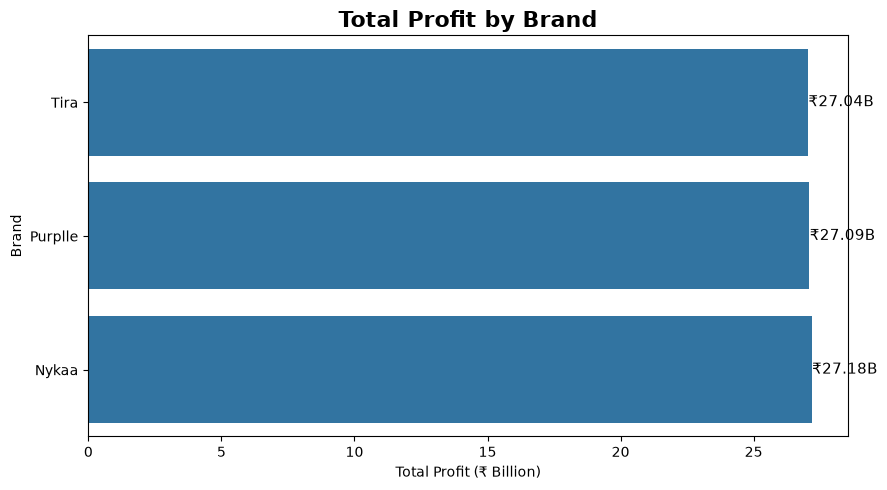

In [7]:
# Visualize Total Profit by Company
brand_profit = (
    df.groupby("Company_Name")["Profit"]
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=brand_profit.values / 1e9,
    y=brand_profit.index
)

plt.title("Total Profit by Brand", fontsize=16, fontweight="bold")
plt.xlabel("Total Profit (₹ Billion)")
plt.ylabel("Brand")

# Add value labels
for i, value in enumerate(brand_profit.values / 1e9):
    ax.text(value + 0.02, i, f"₹{value:.2f}B",
            va="center", fontsize=11)

plt.tight_layout()
plt.show()

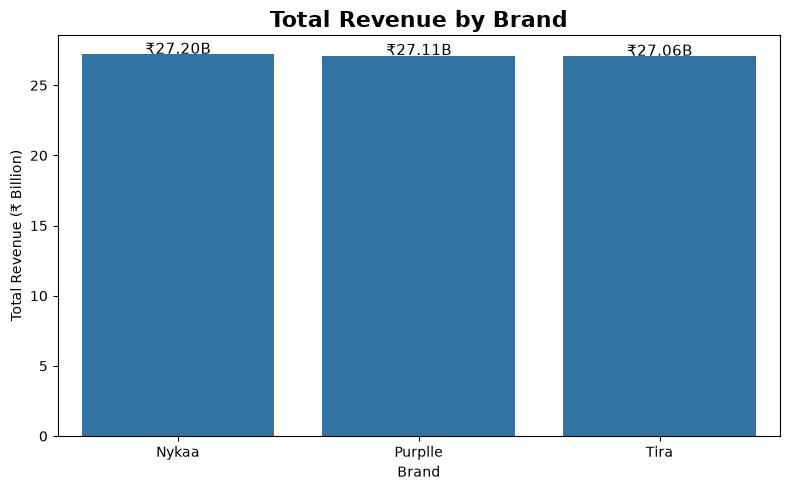

In [8]:
# Total Revenue by Company
brand_revenue = (
    df.groupby("Company_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=brand_revenue.index,
    y=brand_revenue.values / 1e9
)

plt.title("Total Revenue by Brand", fontsize=16, fontweight="bold")
plt.xlabel("Brand")
plt.ylabel("Total Revenue (₹ Billion)")

# Add value labels
for i, value in enumerate(brand_revenue.values / 1e9):
    ax.text(i, value + 0.05, f"₹{value:.2f}B",
            ha="center", fontsize=11)

plt.tight_layout()
plt.show()

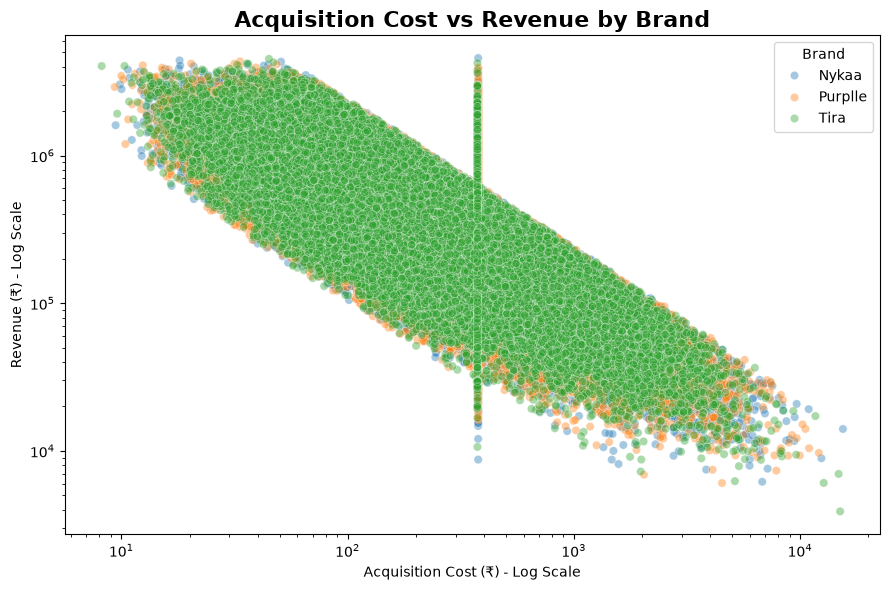

In [9]:
# Scatter plot of Acquisition Cost vs Revenue by Brand
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Acquisition_Cost",
    y="Revenue",
    hue="Company_Name",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Acquisition Cost vs Revenue by Brand",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Acquisition Cost (₹) - Log Scale")
plt.ylabel("Revenue (₹) - Log Scale")
plt.legend(title="Brand")

plt.tight_layout()
plt.show()

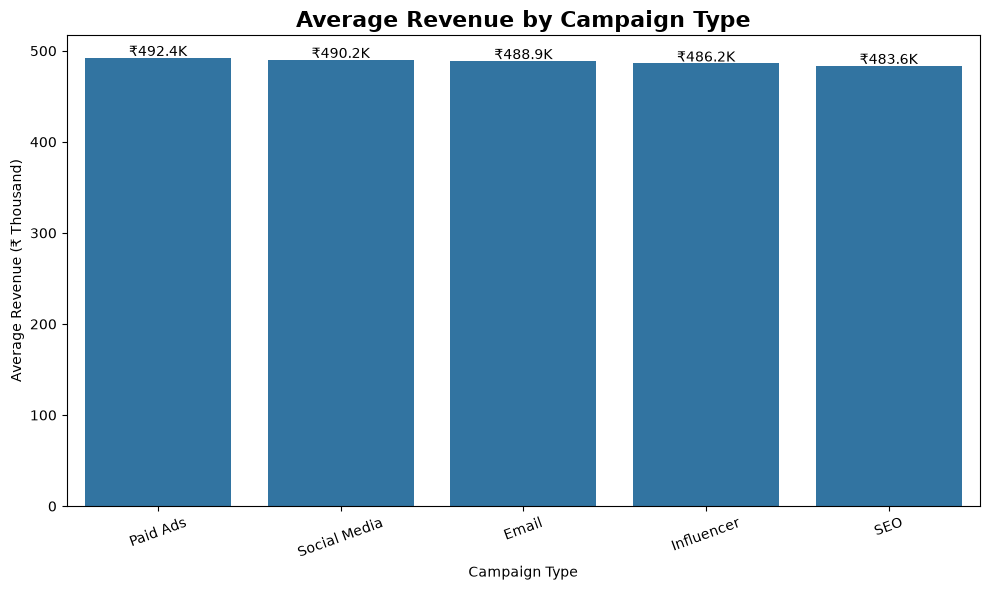

In [10]:
# Average Revenue by Campaign Type
campaign_revenue = (
    df.groupby("Campaign_Type")["Revenue"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=campaign_revenue.index,
    y=campaign_revenue.values / 1e3
)

plt.title(
    "Average Revenue by Campaign Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Campaign Type")
plt.ylabel("Average Revenue (₹ Thousand)")

for i, value in enumerate(campaign_revenue.values / 1e3):
    ax.text(
        i,
        value + 2,
        f"₹{value:.1f}K",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# Quarterly revenue by brand

quarterly_revenue = (
    df.dropna(subset=["Date"])
      .assign(
          Quarter=lambda x: x["Date"].dt.to_period("Q")
      )
      .groupby(["Quarter", "Company_Name"])["Revenue"]
      .sum()
      .reset_index()
)

quarterly_revenue["Quarter_Label"] = (
    quarterly_revenue["Quarter"].astype(str)
)

display(quarterly_revenue)


,Quarter,Company_Name,Revenue,Quarter_Label
0,2024Q3,Nykaa,6.846372e+09,2024Q3
1,2024Q3,Purplle,6.916814e+09,2024Q3
2,2024Q3,Tira,6.861851e+09,2024Q3
3,2024Q4,Nykaa,6.910964e+09,2024Q4
4,2024Q4,Purplle,6.899267e+09,2024Q4
5,2024Q4,Tira,6.768815e+09,2024Q4
6,2025Q1,Nykaa,6.687810e+09,2025Q1
7,2025Q1,Purplle,6.608686e+09,2025Q1
8,2025Q1,Tira,6.776557e+09,2025Q1
9,2025Q2,Nykaa,5.387247e+09,2025Q2


In [12]:
# Identify complete calendar quarters

quarter_campaign_counts = (
    df.dropna(subset=["Date"])
      .assign(
          Quarter=lambda x: x["Date"].dt.to_period("Q")
      )
      .groupby("Quarter")
      .size()
)

quarterly_revenue_complete = quarterly_revenue[
    quarterly_revenue["Quarter"].isin(
        quarter_campaign_counts.index
    )
].copy()

# Keep quarters represented in the available dated data.
# Missing Date rows are intentionally excluded from time-based analysis.
display(quarterly_revenue_complete)


,Quarter,Company_Name,Revenue,Quarter_Label
0,2024Q3,Nykaa,6.846372e+09,2024Q3
1,2024Q3,Purplle,6.916814e+09,2024Q3
2,2024Q3,Tira,6.861851e+09,2024Q3
3,2024Q4,Nykaa,6.910964e+09,2024Q4
4,2024Q4,Purplle,6.899267e+09,2024Q4
5,2024Q4,Tira,6.768815e+09,2024Q4
6,2025Q1,Nykaa,6.687810e+09,2025Q1
7,2025Q1,Purplle,6.608686e+09,2025Q1
8,2025Q1,Tira,6.776557e+09,2025Q1
9,2025Q2,Nykaa,5.387247e+09,2025Q2


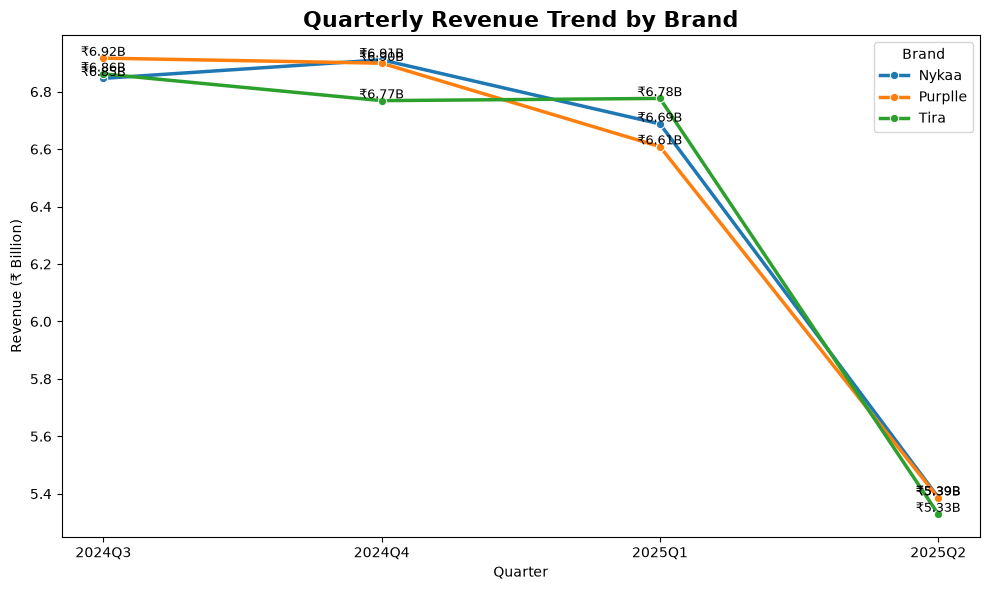

In [13]:
# Create a new column for revenue in billions

quarterly_revenue_complete["Revenue_Billion"] = (
    quarterly_revenue_complete["Revenue"] / 1e9
)

# Line plot of Quarterly Revenue Trend by Brand
plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=quarterly_revenue_complete,
    x="Quarter_Label",
    y="Revenue_Billion",
    hue="Company_Name",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Quarterly Revenue Trend by Brand",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue (₹ Billion)")

# Add value labels to each point
for _, row in quarterly_revenue_complete.iterrows():
    plt.text(
        row["Quarter_Label"],
        row["Revenue_Billion"] + 0.008,
        f"₹{row['Revenue_Billion']:.2f}B",
        ha="center",
        fontsize=9
    )

plt.legend(title="Brand")
plt.tight_layout()
plt.show()


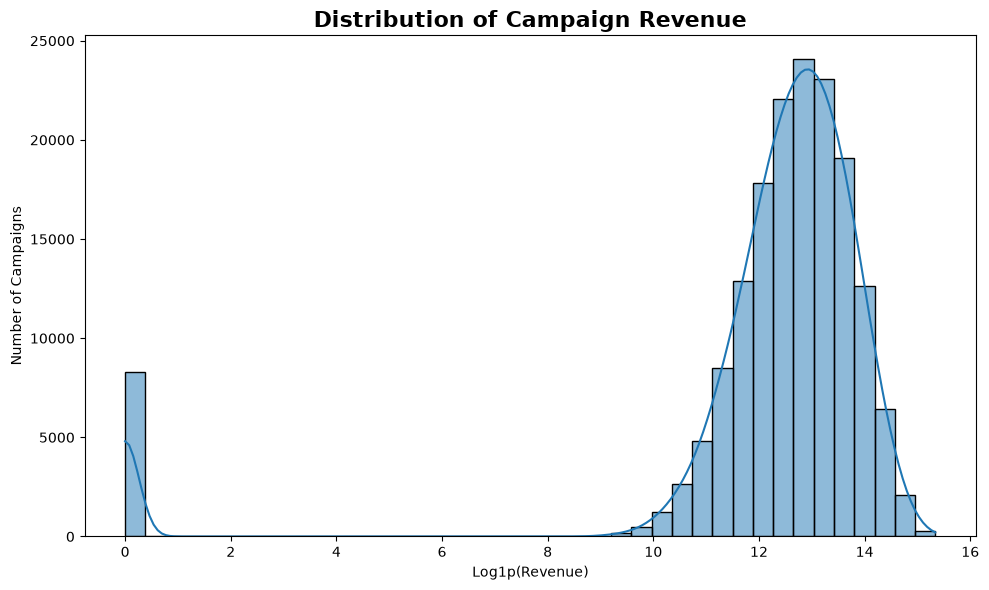

In [14]:
# Log-transformed Revenue distribution

# Revenue can legitimately be 0 because missing Revenue was imputed with 0.
# log1p handles zero safely: log1p(0) = 0.
df["Log_Revenue"] = np.log1p(df["Revenue"])

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Log_Revenue",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Campaign Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Log1p(Revenue)")
plt.ylabel("Number of Campaigns")

plt.tight_layout()
plt.show()


In [15]:
# Final EDA dataset validation

print("Final EDA dataset shape:", df.shape)

print("\nCompany distribution:")
display(df["Company_Name"].value_counts())

print("\nOriginal ROI missing values (retained intentionally):",
      df["ROI"].isna().sum())

print("Date missing values (retained intentionally):",
      df["Date"].isna().sum())

print("\nCalculated ROI missing values:",
      df["Calculated_ROI"].isna().sum())

print("\nRequired EDA/modeling columns present:")
required_columns = [
    "Revenue",
    "Acquisition_Cost",
    "Profit",
    "Profit_Flag",
    "Calculated_ROI",
    "Company_Name",
    "Channel_Google",
    "Channel_WhatsApp",
    "Channel_YouTube",
    "Channel_Email",
    "Channel_Instagram",
    "Channel_Facebook"
]
print(all(col in df.columns for col in required_columns))


Final EDA dataset shape: (166665, 26)

Company distribution:


Company_Name
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64

KeyError: 'ROI'